<a href="https://colab.research.google.com/github/erikachaichuk/trading/blob/main/TRADING_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.ticker as ticker
from statsmodels.stats.stattools import durbin_watson

In [ ]:
df = pd.read_excel("AggregatedData.xlsx")
df.head()

,Date,Ticker,Time,Open,High,Low,Close,Volume
0,2026-02-19 20:30:00,GS,2026-02-19 20:30:00,914.03,917.400,913.720,916.21,165380.0
1,2026-02-19 20:30:00,GS,2019-02-01 20:00:00,913.21,914.660,912.000,913.83,39498.0
2,2026-02-19 20:30:00,GS,2019-02-01 19:30:00,912.28,913.690,910.010,913.15,35466.0
3,2026-02-19 20:30:00,GS,2019-02-01 19:00:00,910.44,912.905,908.590,912.01,36641.0
4,2026-02-19 20:30:00,GS,2019-02-01 18:30:00,907.45,910.900,906.485,910.53,57037.0


In [ ]:
print(df[["Date", "Ticker", "Time"]].head(20))
print("\nUnique dates in Date column:", df["Date"].nunique())
print("Unique dates in Time column:", df["Time"].nunique())
print("\nDate range in Date:", df["Date"].min(), "->", df["Date"].max())
print("Date range in Time:", pd.to_datetime(df["Time"]).min(), "->", pd.to_datetime(df["Time"]).max())

                  Date Ticker                Time
0  2026-02-19 20:30:00     GS 2026-02-19 20:30:00
1  2026-02-19 20:30:00     GS 2019-02-01 20:00:00
2  2026-02-19 20:30:00     GS 2019-02-01 19:30:00
3  2026-02-19 20:30:00     GS 2019-02-01 19:00:00
4  2026-02-19 20:30:00     GS 2019-02-01 18:30:00
5  2026-02-19 20:30:00     GS 2019-02-01 18:00:00
6  2026-02-19 20:30:00     GS 2019-02-01 17:30:00
7  2026-02-19 20:30:00     GS 2019-02-01 17:00:00
8  2026-02-19 20:30:00     GS 2019-02-01 16:30:00
9  2026-02-19 20:30:00     GS 2019-02-01 16:00:00
10 2026-02-19 20:30:00     GS 2019-02-01 15:30:00
11 2026-02-19 20:30:00     GS 2019-02-01 15:00:00
12 2026-02-19 20:30:00     GS 2019-02-01 14:30:00
13 2026-02-18 00:00:00     GS 2018-02-01 20:30:00
14 2026-02-18 00:00:00     GS 2018-02-01 20:00:00
15 2026-02-18 00:00:00     GS 2018-02-01 19:30:00
16 2026-02-18 00:00:00     GS 2018-02-01 19:00:00
17 2026-02-18 00:00:00     GS 2018-02-01 18:30:00
18 2026-02-18 00:00:00     GS 2018-02-01 18:00:00


In [ ]:
df.columns

Index(['Date', 'Ticker', 'Time', 'Open', 'High', 'Low ', 'Close', 'Volume'], dtype='object')

### PART B

In [ ]:
df["MP"] = df["Close"]
df.head()

,Date,Ticker,Time,Open,High,Low,Close,Volume,MP
0,2026-02-19 20:30:00,GS,2026-02-19 20:30:00,914.03,917.400,913.720,916.21,165380.0,916.21
1,2026-02-19 20:30:00,GS,2019-02-01 20:00:00,913.21,914.660,912.000,913.83,39498.0,913.83
2,2026-02-19 20:30:00,GS,2019-02-01 19:30:00,912.28,913.690,910.010,913.15,35466.0,913.15
3,2026-02-19 20:30:00,GS,2019-02-01 19:00:00,910.44,912.905,908.590,912.01,36641.0,912.01
4,2026-02-19 20:30:00,GS,2019-02-01 18:30:00,907.45,910.900,906.485,910.53,57037.0,910.53


In [ ]:
# Sort
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
df["Time_parsed"] = pd.to_datetime(df["Time"]).dt.time

# Sort by ticker, date, then intraday time
df = df.sort_values(["Ticker", "Date", "Time_parsed"]).copy()

# Verify
print(df[["Ticker", "Date", "Time_parsed"]].head(20))
print("\nUnique times:", sorted(df["Time_parsed"].unique()))
df.head()

      Ticker       Date Time_parsed
34194     BA 2024-01-12    14:30:00
34193     BA 2024-01-12    15:00:00
34192     BA 2024-01-12    15:30:00
34191     BA 2024-01-12    16:00:00
34190     BA 2024-01-12    16:30:00
34189     BA 2024-01-12    17:00:00
34188     BA 2024-01-12    17:30:00
34187     BA 2024-01-12    18:00:00
34186     BA 2024-01-12    18:30:00
34185     BA 2024-01-12    19:00:00
34184     BA 2024-01-12    19:30:00
34183     BA 2024-01-12    20:00:00
34182     BA 2024-01-12    20:30:00
34181     BA 2024-01-16    14:30:00
34180     BA 2024-01-16    15:00:00
34179     BA 2024-01-16    15:30:00
34178     BA 2024-01-16    16:00:00
34177     BA 2024-01-16    16:30:00
34176     BA 2024-01-16    17:00:00
34175     BA 2024-01-16    17:30:00

Unique times: [datetime.time(13, 30), datetime.time(14, 0), datetime.time(14, 30), datetime.time(15, 0), datetime.time(15, 30), datetime.time(16, 0), datetime.time(16, 30), datetime.time(17, 0), datetime.time(17, 30), datetime.time(18, 0), dat

,Date,Ticker,Time,Open,High,Low,Close,Volume,MP,Time_parsed
34194,2024-01-12,BA,2026-12-01 14:30:00,219.970,222.070,218.540,219.633,1676000.0,219.633,14:30:00
34193,2024-01-12,BA,2026-12-01 15:00:00,219.620,219.850,218.560,219.099,637732.0,219.099,15:00:00
34192,2024-01-12,BA,2026-12-01 15:30:00,219.135,219.450,218.271,218.910,683518.0,218.910,15:30:00
34191,2024-01-12,BA,2026-12-01 16:00:00,218.950,219.250,218.320,218.875,443917.0,218.875,16:00:00
34190,2024-01-12,BA,2026-12-01 16:30:00,218.860,218.895,218.010,218.060,407333.0,218.060,16:30:00


In [ ]:
# Compute variabes in order
df["MP"] = df["Close"]
df["DeltaMP"] = df.groupby("Ticker")["MP"].diff(1)
df["D"] = np.where(
    df["DeltaMP"].isna(),
    np.nan,
    np.where(df["DeltaMP"] >= 0, 1, -1)
)
df["SignedSize"] = df["D"] * df["Volume"]
df["DeltaD"] = df.groupby("Ticker")["D"].diff(1)

# Verify
print(df[["Ticker", "Date", "Time_parsed", "MP", "DeltaMP", "D", "SignedSize", "DeltaD"]].head(20))

      Ticker       Date Time_parsed       MP  DeltaMP    D  SignedSize  DeltaD
34194     BA 2024-01-12    14:30:00  219.633      NaN  NaN         NaN     NaN
34193     BA 2024-01-12    15:00:00  219.099   -0.534 -1.0   -637732.0     NaN
34192     BA 2024-01-12    15:30:00  218.910   -0.189 -1.0   -683518.0     0.0
34191     BA 2024-01-12    16:00:00  218.875   -0.035 -1.0   -443917.0     0.0
34190     BA 2024-01-12    16:30:00  218.060   -0.815 -1.0   -407333.0     0.0
34189     BA 2024-01-12    17:00:00  217.250   -0.810 -1.0   -667227.0     0.0
34188     BA 2024-01-12    17:30:00  217.580    0.330  1.0    505506.0     2.0
34187     BA 2024-01-12    18:00:00  218.060    0.480  1.0    381039.0     0.0
34186     BA 2024-01-12    18:30:00  218.060    0.000  1.0    249209.0     0.0
34185     BA 2024-01-12    19:00:00  217.690   -0.370 -1.0   -288280.0    -2.0
34184     BA 2024-01-12    19:30:00  217.125   -0.565 -1.0   -334283.0     0.0
34183     BA 2024-01-12    20:00:00  217.770    0.64

In [ ]:
df = df[["Ticker", "Date", "Time_parsed", "MP", "DeltaMP", "D", "SignedSize", "DeltaD", "Volume", "Close"]].copy()

In [ ]:
# Estimate PI and TI from GM regression: DeltaMP = DeltaD * TI + PI * D + epsi
def estimate_pi_ti(window: pd.DataFrame, min_obs: int = 30) -> dict:
    w = window.dropna(subset=["DeltaMP", "D", "DeltaD"])
    n = len(w)

    # NA handling
    if n < min_obs:
        return {"TI": np.nan, "PI": np.nan, "n_obs": n, "r2": np.nan}

    # Dependent variable: price change
    y = w["DeltaMP"].astype(float)

    # Regressors: change in order direction (DeltaD) and order direction (D)
    X = sm.add_constant(w[["DeltaD", "D"]].astype(float))

    # OLS
    model = sm.OLS(y, X).fit()

    return {
        "TI": model.params.get("DeltaD", np.nan), # transitory impact
        "PI": model.params.get("D", np.nan), # permanent impact
        "n_obs": n,
        "r2": model.rsquared
    }

# Run PI/TI estim for all tickers over overlapping 5-day windows

results = []

for ticker, g in df.groupby("Ticker", sort=False):

    # Sort by date and intraday time within each ticker
    g = g.sort_values(["Date", "Time_parsed"]).copy()

    # Get sorted list of unique trading days for this ticker
    days = pd.Index(g["Date"].dt.normalize().unique()).sort_values()

    # Slide a 5-day window: [day d, day d+4], moving forward one day at a time
    for start_idx in range(0, len(days) - 5 + 1):
        start_day = days[start_idx]
        end_day = days[start_idx + 4]

        # Select all intraday observations within this 5-day window
        window = g.loc[(g["Date"].dt.normalize() >= start_day) & (g["Date"].dt.normalize() <= end_day)]

        # Estimate PI and TI for this ticker-window
        est = estimate_pi_ti(window, min_obs=30)

        results.append({"Ticker": ticker, "window_start": start_day, "window_end": end_day,**est})

# Combine all results into a dataframe — one row per ticker per 5-day window
pi_ti = pd.DataFrame(results).sort_values(["Ticker", "window_start"]).reset_index(drop=True)
pi_ti.head()

,Ticker,window_start,window_end,TI,PI,n_obs,r2
0,BA,2024-01-12,2024-01-19,-0.248836,1.037658,63,0.251328
1,BA,2024-01-16,2024-01-22,-0.213413,1.033357,65,0.259721
2,BA,2024-01-17,2024-01-23,-0.025859,0.670217,65,0.504040
3,BA,2024-01-18,2024-01-24,-0.041995,0.741546,65,0.499591
4,BA,2024-01-19,2024-01-25,-0.158130,1.057908,65,0.328916


In [ ]:
vix = pd.read_excel("VIX_History.xlsx")

vix["Date"] = pd.to_datetime(vix["Date"], dayfirst=True)

vix["VIX"] = (
    vix["Last Price"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
)


In [ ]:
print(vix["Date"].head())
print(pi_ti["window_start"].head())

0   2026-02-27
1   2026-02-26
2   2026-02-25
3   2026-02-24
4   2026-02-23
Name: Date, dtype: datetime64[ns]
0   2024-01-12
1   2024-01-16
2   2024-01-17
3   2024-01-18
4   2024-01-19
Name: window_start, dtype: datetime64[ns]


In [ ]:
# Median split
median_vix = vix["VIX"].median()
vix["HighVIX"] = (vix["VIX"] >= median_vix).astype(int)

pi_ti["window_start"] = pd.to_datetime(pi_ti["window_start"])

# Merge
pi_ti = pi_ti.merge(vix[["Date", "HighVIX"]], left_on="window_start", right_on="Date", how="left")

pi_ti.drop(columns="Date", inplace=True)

large_caps = ["GS","GE","MCD","DIS","BA"]
small_caps = ["BKSY","TUYA","SB","HYMC","OPFI"]

pi_ti["Size"] = np.where(pi_ti["Ticker"].isin(large_caps), "Large", "Small")

# Convert HighVIX dummy into labels
pi_ti["VIX_Regime"] = np.where(pi_ti["HighVIX"] == 1, "High VIX", "Low VIX")

# High vs Low VIX
table_vix = (pi_ti.groupby("VIX_Regime")[["PI","TI"]].mean().round(4))

# Large vs Small
table_size = (pi_ti.groupby("Size")[["PI","TI"]].mean().round(4))


In [ ]:
print("VIX date range:", vix["Date"].min(), "-", vix["Date"].max())
print("pi_ti date range:", pi_ti["window_start"].min(), "-", pi_ti["window_start"].max())
print("\nHighVIX null %:", pi_ti["HighVIX"].isnull().mean())

VIX date range: 2024-01-02 00:00:00 - 2026-02-27 00:00:00
pi_ti date range: 2024-01-12 00:00:00 - 2026-02-12 00:00:00

HighVIX null %: 0.0


In [ ]:
# Combined
table_combined = (pi_ti.groupby(["VIX_Regime","Size"])[["PI","TI"]].mean().round(4))

print("\n===== High vs Low VIX =====")
print(table_vix)

print("\n===== Large vs Small Stocks =====")
print(table_size)

print("\n===== Combined (VIX × Size) =====")
print(table_combined)


===== High vs Low VIX =====
                PI      TI
VIX_Regime                
High VIX    0.5002 -0.0065
Low VIX     0.3764 -0.0021

===== Large vs Small Stocks =====
           PI      TI
Size                 
Large  0.8149 -0.0088
Small  0.0629  0.0002

===== Combined (VIX × Size) =====
                      PI      TI
VIX_Regime Size                 
High VIX   Large  0.9308 -0.0125
           Small  0.0696 -0.0004
Low VIX    Large  0.6968 -0.0049
           Small  0.0561  0.0008


In [ ]:
# Kyle lambda estimation
def estimate_lambda(window: pd.DataFrame, min_obs: int = 30) -> dict:

    w = window.dropna(subset=["DeltaMP", "SignedSize"])
    n = len(w)

    if n < min_obs:
        return {"Lambda": np.nan, "n_obs": n, "r2": np.nan}

    y = w["DeltaMP"].astype(float)
    X = w[["SignedSize"]].astype(float)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    return {
        "Lambda": model.params.get("SignedSize", np.nan),
        "n_obs": n,
        "r2": model.rsquared
    }

In [ ]:
# Run across all tickers and 5-day windows for lambda df building
results_lambda = []

for ticker, g in df.groupby("Ticker", sort=False):

    # Sort by date and intraday time within each ticker
    g = g.sort_values(["Date", "Time_parsed"]).copy()

    # Get sorted list of unique trading days for this ticker
    days = pd.Index(g["Date"].dt.normalize().unique()).sort_values()

    # Slide a 5-day window: [day d, day d+4]
    for start_idx in range(0, len(days) - 5 + 1):
        start_day = days[start_idx]
        end_day = days[start_idx + 4]

        # Select all intraday observations within this 5-day window
        window = g.loc[(g["Date"].dt.normalize() >= start_day) & (g["Date"].dt.normalize() <= end_day)]

        # Estimate lambda for this ticker-window
        est = estimate_lambda(window)

        results_lambda.append({
            "Ticker": ticker,
            "window_start": start_day,
            "window_end": end_day,
            **est
        })

# One row per ticker per 5-day window
lambda_df = pd.DataFrame(results_lambda)
lambda_df.head()

,Ticker,window_start,window_end,Lambda,n_obs,r2
0,BA,2024-01-12,2024-01-19,8.565246e-07,64,0.460441
1,BA,2024-01-16,2024-01-22,8.546295e-07,65,0.463358
2,BA,2024-01-17,2024-01-23,7.126643e-07,65,0.615752
3,BA,2024-01-18,2024-01-24,8.622577e-07,65,0.590012
4,BA,2024-01-19,2024-01-25,1.363955e-06,65,0.682484


In [ ]:
lambda_df = lambda_df.merge(vix[["Date", "HighVIX"]], left_on="window_start", right_on="Date", how="left").drop(columns="Date")

large_caps = ["GS","GE","MCD","DIS","BA"]

lambda_df["Size"] = np.where(lambda_df["Ticker"].isin(large_caps), "Large", "Small")

lambda_df["VIX_Regime"] = np.where(lambda_df["HighVIX"] == 1, "High VIX", "Low VIX")

In [ ]:
print("HighVIX null %:", lambda_df["HighVIX"].isnull().mean())
print(lambda_df["HighVIX"].value_counts())

HighVIX null %: 0.0
HighVIX
1    2640
0    2590
Name: count, dtype: int64


In [ ]:
print("\n===== Lambda: High vs Low VIX =====")
print(lambda_df.groupby("VIX_Regime")["Lambda"].mean().round(10))

print("\n===== Lambda: Large vs Small =====")
print(lambda_df.groupby("Size")["Lambda"].mean().round(6))

print("\n===== Lambda: VIX × Size =====")
print(lambda_df.groupby(["VIX_Regime","Size"])["Lambda"].mean().round(6))


===== Lambda: High vs Low VIX =====
VIX_Regime
High VIX    0.000004
Low VIX     0.000004
Name: Lambda, dtype: float64

===== Lambda: Large vs Small =====
Size
Large    0.000006
Small    0.000002
Name: Lambda, dtype: float64

===== Lambda: VIX × Size =====
VIX_Regime  Size 
High VIX    Large    0.000007
            Small    0.000001
Low VIX     Large    0.000006
            Small    0.000002
Name: Lambda, dtype: float64


In [ ]:
# c) Percentiles for PI and TI (in addition to means)
# Uses existing pi_ti dataframe in your notebook

def pct_table(data, group_cols, value_cols=("PI", "TI"), pcts=(0.10, 0.50, 0.90), round_to=4):
    """
    Returns mean + percentile table for each value_col grouped by group_cols.
    """
    def agg_fn(x):
        return pd.Series({
            "mean": x.mean(),
            "p10": x.quantile(pcts[0]),
            "median": x.quantile(pcts[1]),
            "p90": x.quantile(pcts[2]),
            "n": x.notna().sum()
        })

    out = {}
    for col in value_cols:
        out[col] = (data.groupby(group_cols)[col]
                      .apply(agg_fn)
                      .reset_index())
        out[col] = out[col].round(round_to)
    return out

# By VIX regime
pi_ti_pct_vix = pct_table(pi_ti, ["VIX_Regime"])
print("\n===== PI percentiles by VIX regime =====")
print(pi_ti_pct_vix["PI"].to_string(index=False))

print("\n===== TI percentiles by VIX regime =====")
print(pi_ti_pct_vix["TI"].to_string(index=False))

# By Size
pi_ti_pct_size = pct_table(pi_ti, ["Size"])
print("\n===== PI percentiles by Size =====")
print(pi_ti_pct_size["PI"].to_string(index=False))

print("\n===== TI percentiles by Size =====")
print(pi_ti_pct_size["TI"].to_string(index=False))

# By VIX × Size (very useful for write-up)
pi_ti_pct_vix_size = pct_table(pi_ti, ["VIX_Regime", "Size"])
print("\n===== PI percentiles by VIX × Size =====")
print(pi_ti_pct_vix_size["PI"].to_string(index=False))

print("\n===== TI percentiles by VIX × Size =====")
print(pi_ti_pct_vix_size["TI"].to_string(index=False))



===== PI percentiles by VIX regime =====
VIX_Regime level_1        PI
  High VIX    mean    0.5002
  High VIX     p10    0.0138
  High VIX  median    0.2143
  High VIX     p90    1.2130
  High VIX       n 2640.0000
   Low VIX    mean    0.3764
   Low VIX     p10    0.0133
   Low VIX  median    0.1945
   Low VIX     p90    0.9400
   Low VIX       n 2590.0000

===== TI percentiles by VIX regime =====
VIX_Regime level_1        TI
  High VIX    mean   -0.0065
  High VIX     p10   -0.0954
  High VIX  median    0.0001
  High VIX     p90    0.0856
  High VIX       n 2640.0000
   Low VIX    mean   -0.0021
   Low VIX     p10   -0.0764
   Low VIX  median    0.0002
   Low VIX     p90    0.0753
   Low VIX       n 2590.0000

===== PI percentiles by Size =====
 Size level_1        PI
Large    mean    0.8149
Large     p10    0.2378
Large  median    0.5983
Large     p90    1.6591
Large       n 2615.0000
Small    mean    0.0629
Small     p10    0.0107
Small  median    0.0252
Small     p90    0.1447
Sm

In [ ]:
# PI as a Percentage

df["Date_norm"] = pd.to_datetime(df["Date"]).dt.normalize()
pi_ti["window_start"] = pd.to_datetime(pi_ti["window_start"]).dt.normalize()
pi_ti["window_end"]   = pd.to_datetime(pi_ti["window_end"]).dt.normalize()

# Daily aggregation of absolute price changes per ticker-day
daily_abs = (
    df.dropna(subset=["DeltaMP"])
      .assign(abs_dm=lambda x: np.abs(x["DeltaMP"].astype(float)))
      .groupby(["Ticker", "Date_norm"], as_index=False)
      .agg(abs_sum=("abs_dm", "sum"),
           n_obs=("abs_dm", "size"))
      .sort_values(["Ticker", "Date_norm"])
)

# 5-day rolling sums to match window [d, d+4]
daily_abs["roll_abs_sum"] = (
    daily_abs.groupby("Ticker")["abs_sum"]
             .rolling(5, min_periods=5)
             .sum()
             .reset_index(level=0, drop=True)
)

daily_abs["roll_n_obs"] = (
    daily_abs.groupby("Ticker")["n_obs"]
             .rolling(5, min_periods=5)
             .sum()
             .reset_index(level=0, drop=True)
)

# ES_proxy for the 5-day window ending on Date_norm
daily_abs["ES_proxy"] = 2.0 * (daily_abs["roll_abs_sum"] / daily_abs["roll_n_obs"])

# start_date for that window is 4 trading days earlier within each ticker sequence
daily_abs["window_start"] = (
    daily_abs.groupby("Ticker")["Date_norm"].shift(4)
)
daily_abs["window_end"] = daily_abs["Date_norm"]

es_map = daily_abs.dropna(subset=["window_start", "ES_proxy"])[
    ["Ticker", "window_start", "window_end", "ES_proxy"]
].copy()

# Merge ES_proxy into pi_ti at the same (Ticker, window_start, window_end)
pi_ti_es = pi_ti.merge(
    es_map,
    on=["Ticker", "window_start", "window_end"],
    how="left"
)

# Compute PI as a percent of ES_proxy
pi_ti_es["PI_pct"] = 100.0 * np.abs(pi_ti_es["PI"]) / pi_ti_es["ES_proxy"]
pi_ti_es.loc[~np.isfinite(pi_ti_es["PI_pct"]), "PI_pct"] = np.nan

def brief_range_statement(data, regime_label):
    sub = data[data["VIX_Regime"] == regime_label].dropna(subset=["PI_pct"])
    p10 = sub["PI_pct"].quantile(0.10)
    p90 = sub["PI_pct"].quantile(0.90)
    n_days = sub["window_start"].nunique()
    return p10, p90, n_days

for reg in ["Low VIX", "High VIX"]:
    p10, p90, n_days = brief_range_statement(pi_ti_es, reg)
    print(
        f"{reg}: PI_(i,d) ranges between {p10:.1f}–{p90:.1f}% of the effective-spread proxy "
        f"during the total of {n_days} {reg} days."
    )

pi_ti_es.to_csv("pi_ti_with_ESproxy_and_PI_pct.csv", index=False)
print("\nSaved: pi_ti_with_ESproxy_and_PI_pct.csv")

Low VIX: PI_(i,d) ranges between 40.0–60.6% of the effective-spread proxy during the total of 259 Low VIX days.
High VIX: PI_(i,d) ranges between 40.1–59.8% of the effective-spread proxy during the total of 264 High VIX days.

Saved: pi_ti_with_ESproxy_and_PI_pct.csv


In [ ]:
# d) Percentiles for Kyle's Lambda

# Ensure correct column name
LAMBDA_COL = "Lambda"

def summarize_lambda_percentiles(data, group_cols):
    """
    Compute mean, P10, median, P90 and count for Lambda.
    """
    return (
        data.groupby(group_cols)[LAMBDA_COL]
            .agg(
                mean="mean",
                p10=lambda x: x.quantile(0.10),
                median=lambda x: x.quantile(0.50),
                p90=lambda x: x.quantile(0.90),
                n="count"
            )
            .reset_index()
    )

# By VIX regime
lambda_vix = summarize_lambda_percentiles(lambda_df, ["VIX_Regime"])
print("\n===== Lambda Percentiles by VIX Regime =====")
print(lambda_vix)

# By Size
lambda_size = summarize_lambda_percentiles(lambda_df, ["Size"])
print("\n===== Lambda Percentiles by Size =====")
print(lambda_size)

# By VIX × Size
lambda_vix_size = summarize_lambda_percentiles(lambda_df, ["VIX_Regime", "Size"])
print("\n===== Lambda Percentiles by VIX × Size =====")
print(lambda_vix_size)


===== Lambda Percentiles by VIX Regime =====
  VIX_Regime      mean           p10    median       p90     n
0   High VIX  0.000004  2.627219e-07  0.000001  0.000012  2640
1    Low VIX  0.000004  2.854674e-07  0.000001  0.000012  2590

===== Lambda Percentiles by Size =====
    Size      mean           p10        median       p90     n
0  Large  0.000006  5.423863e-07  2.457186e-06  0.000021  2615
1  Small  0.000002  1.385848e-07  8.210496e-07  0.000002  2615

===== Lambda Percentiles by VIX × Size =====
  VIX_Regime   Size      mean           p10        median       p90     n
0   High VIX  Large  0.000007  5.865871e-07  2.695839e-06  0.000024  1320
1   High VIX  Small  0.000001  1.290332e-07  8.005782e-07  0.000002  1320
2    Low VIX  Large  0.000006  5.120488e-07  2.253447e-06  0.000016  1295
3    Low VIX  Small  0.000002  1.653849e-07  8.404157e-07  0.000004  1295


### PART C

In [ ]:
df_day = pd.read_excel('Daily.xlsx')
df_day.head()

,Dates,Ticker,PX_LAST,PX_VOLUME,CUR_MKT_CAP
0,2024-01-12,GS,377.75,2223834,127552.7199
1,2024-01-15,GS,377.75,2223834,127552.7199
2,2024-01-16,GS,380.45,3926571,128464.4138
3,2024-01-17,GS,377.18,2415333,127360.2512
4,2024-01-18,GS,376.91,1771217,127269.0818


In [ ]:
# Check for duplicate values
print(df_day[df_day["Ticker"] == "GS"][["Dates", "PX_LAST", "PX_VOLUME"]].head(10))

# Check for duplicate dates per ticker
dupes = df_day.duplicated(subset=["Ticker", "Dates"]).sum()
print(f"\nDuplicate ticker-date pairs: {dupes}")

       Dates  PX_LAST  PX_VOLUME
0 2024-01-12   377.75    2223834
1 2024-01-15   377.75    2223834
2 2024-01-16   380.45    3926571
3 2024-01-17   377.18    2415333
4 2024-01-18   376.91    1771217
5 2024-01-19   382.20    2603278
6 2024-01-22   385.96    2922749
7 2024-01-23   380.77    3313294
8 2024-01-24   379.40    2235811
9 2024-01-25   382.70    2376324

Duplicate ticker-date pairs: 0


In [ ]:
print(df_day[df_day["Dates"].isin(["2024-01-12", "2024-01-15"])][["Dates", "Ticker", "PX_LAST", "PX_VOLUME"]])

          Dates Ticker   PX_LAST  PX_VOLUME
0    2024-01-12     GS  377.7500    2223834
1    2024-01-15     GS  377.7500    2223834
550  2024-01-12     GE  103.5115    4501735
551  2024-01-15     GE  103.5115    4501735
1100 2024-01-12    MCD  293.4700    1714818
1101 2024-01-15    MCD  293.4700    1714818
1650 2024-01-12    DIS   90.3500   11919448
1651 2024-01-15    DIS   90.3500   11919448
2200 2024-01-12     BA  217.7000   11285521
2201 2024-01-15     BA  217.7000   11285521
2750 2024-01-12   BKSY   10.3200      34553
2751 2024-01-15   BKSY   10.3200      34553
3300 2024-01-12   TUYA    2.2400     211736
3301 2024-01-15   TUYA    2.2400     211736
3850 2024-01-12     SB    3.8700     554730
3851 2024-01-15     SB    3.8700     554730
4400 2024-01-12   HYMC    2.3900     167623
4401 2024-01-15   HYMC    2.3900     167623
4950 2024-01-12   OPFI    4.5200     168929
4951 2024-01-15   OPFI    4.5200     168929


/tmp/ipykernel_954/1478013512.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  print(df_day[df_day["Dates"].isin(["2024-01-12", "2024-01-15"])][["Dates", "Ticker", "PX_LAST", "PX_VOLUME"]])


In [ ]:
# Check 2024-01-15 across all datasets
print("Intraday data:")
print(df[df["Date"] == "2024-01-15"]["Ticker"].value_counts())

print("\nDaily data:")
print(df_day[df_day["Dates"] == "2024-01-15"]["Ticker"].value_counts())

print("\nVIX data:")
print(vix[vix["Date"] == "2024-01-15"])

Intraday data:
Series([], Name: count, dtype: int64)

Daily data:
Ticker
GS      1
GE      1
MCD     1
DIS     1
BA      1
BKSY    1
TUYA    1
SB      1
HYMC    1
OPFI    1
Name: count, dtype: int64

VIX data:
          Date  Last Price    VIX  HighVIX
548 2024-01-15       13.25  13.25        0


In [ ]:
# Checking for duplicated rows
df_day = df_day.sort_values(["Ticker", "Dates"])
df_day["prev_price"] = df_day.groupby("Ticker")["PX_LAST"].shift(1)
df_day["prev_vol"] = df_day.groupby("Ticker")["PX_VOLUME"].shift(1)

carried = (df_day["PX_LAST"] == df_day["prev_price"]) & (df_day["PX_VOLUME"] == df_day["prev_vol"])

print(f"Carried forward rows: {carried.sum()}")
print(df_day[carried][["Ticker", "Dates", "PX_LAST", "PX_VOLUME"]])

Carried forward rows: 230
     Ticker      Dates  PX_LAST  PX_VOLUME
2201     BA 2024-01-15   217.70   11285521
2226     BA 2024-02-19   203.89    5986529
2255     BA 2024-03-29   192.99    4471666
2296     BA 2024-05-27   174.52    9489380
2313     BA 2024-06-19   174.99    6179870
...     ...        ...      ...        ...
3789   TUYA 2025-11-27     2.21    1332520
3809   TUYA 2025-12-25     2.21     330162
3814   TUYA 2026-01-01     2.11     755297
3826   TUYA 2026-01-19     2.25    1839106
3846   TUYA 2026-02-16     2.23    1119643

[230 rows x 4 columns]


In [ ]:
# Check if these dates are actual trading days in intraday data
carried_dates = df_day[carried]["Dates"].dt.normalize().unique()
intraday_dates = df["Date"].dt.normalize().unique()

# Dates in carried-forward that are NOT in intraday
not_in_intraday = set([d for d in carried_dates if d not in intraday_dates])

# Check how many of those are in VIX
vix_dates = set(vix["Date"].dt.normalize().unique())
in_vix_not_intraday = not_in_intraday & vix_dates
not_in_either = not_in_intraday - vix_dates

print(f"Carried forward dates not in intraday but in VIX: {len(in_vix_not_intraday)}")
print(f"Carried forward dates not in intraday OR VIX: {len(not_in_either)}")
print(sorted(not_in_either))

Carried forward dates not in intraday but in VIX: 17
Carried forward dates not in intraday OR VIX: 6
[Timestamp('2024-03-29 00:00:00'), Timestamp('2024-12-25 00:00:00'), Timestamp('2025-01-01 00:00:00'), Timestamp('2025-04-18 00:00:00'), Timestamp('2025-12-25 00:00:00'), Timestamp('2026-01-01 00:00:00')]


In [ ]:
# Align daily data to intraday trading days only
intraday_dates = df["Date"].dt.normalize().unique()
df_day = df_day[df_day["Dates"].dt.normalize().isin(intraday_dates)].copy()
df_day = df_day.drop(columns=["prev_price", "prev_vol"]).copy()

# Also remove non-trading days from VIX
vix = vix[vix["Date"].dt.normalize().isin(intraday_dates)].copy()

print("Daily shape after filter:", df_day.shape)
print("VIX shape after filter:", vix.shape)
print("Remaining carried forward rows:",
      ((df_day.groupby("Ticker")["PX_LAST"].shift(1) == df_day["PX_LAST"]) &
       (df_day.groupby("Ticker")["PX_VOLUME"].shift(1) == df_day["PX_VOLUME"])).sum())

Daily shape after filter: (5270, 5)
VIX shape after filter: (527, 4)
Remaining carried forward rows: 0


In [ ]:
df_day.dtypes

,0
Dates,datetime64[ns]
Ticker,object
PX_LAST,float64
PX_VOLUME,int64
CUR_MKT_CAP,float64


In [ ]:
# Shift by ticker
df_day = df_day.sort_values(["Ticker", "Dates"])
df_day["Log_Returns"] = df_day.groupby("Ticker")["PX_LAST"].transform(lambda x: np.log(x / x.shift(1)))

print(df_day[["Dates", "Ticker", "PX_LAST", "Log_Returns"]].head(10))

          Dates Ticker  PX_LAST  Log_Returns
2200 2024-01-12     BA   217.70          NaN
2202 2024-01-16     BA   200.52    -0.082204
2203 2024-01-17     BA   203.06     0.012588
2204 2024-01-18     BA   211.61     0.041243
2205 2024-01-19     BA   215.02     0.015986
2206 2024-01-22     BA   214.93    -0.000419
2207 2024-01-23     BA   211.50    -0.016087
2208 2024-01-24     BA   214.13     0.012358
2209 2024-01-25     BA   201.88    -0.058910
2210 2024-01-26     BA   205.47     0.017627


In [ ]:
# Sort
df_day = df_day.sort_values(['Ticker', 'Dates'])

# Use transform to keep the index aligned
df_day['Log_Returns'] = df_day.groupby('Ticker')['PX_LAST'].transform(lambda x: np.log(x / x.shift(1)))

# Drop NaNs (losing the first date of each security)
df_day.dropna(subset=['Log_Returns'], inplace=True)

print(df_day[['Dates', 'PX_LAST', 'Log_Returns']].head(10))
print("\n")
print(df_day[['Dates', 'PX_LAST', 'Log_Returns']].tail(10))

          Dates  PX_LAST  Log_Returns
2202 2024-01-16   200.52    -0.082204
2203 2024-01-17   203.06     0.012588
2204 2024-01-18   211.61     0.041243
2205 2024-01-19   215.02     0.015986
2206 2024-01-22   214.93    -0.000419
2207 2024-01-23   211.50    -0.016087
2208 2024-01-24   214.13     0.012358
2209 2024-01-25   201.88    -0.058910
2210 2024-01-26   205.47     0.017627
2211 2024-01-29   205.19    -0.001364


          Dates  PX_LAST  Log_Returns
3839 2026-02-05     2.07     0.009709
3840 2026-02-06     2.16     0.042560
3841 2026-02-09     2.17     0.004619
3842 2026-02-10     2.22     0.022780
3843 2026-02-11     2.16    -0.027399
3844 2026-02-12     2.18     0.009217
3845 2026-02-13     2.23     0.022677
3847 2026-02-17     2.16    -0.031893
3848 2026-02-18     2.11    -0.023420
3849 2026-02-19     2.12     0.004728


In [ ]:
df_day['D_VOL'] = df_day['PX_LAST'] * df_day['PX_VOLUME']
df_day.head()

,Dates,Ticker,PX_LAST,PX_VOLUME,CUR_MKT_CAP,Log_Returns,D_VOL
2202,2024-01-16,BA,200.52,35289981,121309.9473,-0.082204,7.076347e+09
2203,2024-01-17,BA,203.06,20140113,122846.5884,0.012588,4.089651e+09
2204,2024-01-18,BA,211.61,20046757,128019.1400,0.041243,4.242094e+09
2205,2024-01-19,BA,215.02,14345444,130082.1109,0.015986,3.084557e+09
2206,2024-01-22,BA,214.93,10760764,130027.6630,-0.000419,2.312811e+09


In [ ]:
df_day["Amihud"] = (np.abs(df_day["Log_Returns"]) / df_day["D_VOL"]) * 1000000
print(df_day[["Ticker", "Dates", "PX_LAST", "Log_Returns", "D_VOL", "Amihud"]].head(10))

     Ticker      Dates  PX_LAST  Log_Returns         D_VOL        Amihud
2202     BA 2024-01-16   200.52    -0.082204  7.076347e+09  1.161672e-05
2203     BA 2024-01-17   203.06     0.012588  4.089651e+09  3.077893e-06
2204     BA 2024-01-18   211.61     0.041243  4.242094e+09  9.722428e-06
2205     BA 2024-01-19   215.02     0.015986  3.084557e+09  5.182620e-06
2206     BA 2024-01-22   214.93    -0.000419  2.312811e+09  1.810149e-07
2207     BA 2024-01-23   211.50    -0.016087  1.919760e+09  8.379900e-06
2208     BA 2024-01-24   214.13     0.012358  3.237457e+09  3.817289e-06
2209     BA 2024-01-25   201.88    -0.058910  4.464066e+09  1.319646e-05
2210     BA 2024-01-26   205.47     0.017627  2.036453e+09  8.655527e-06
2211     BA 2024-01-29   205.19    -0.001364  1.546188e+09  8.819487e-07


In [ ]:
print(df_day["Amihud"].describe())
print(df_day[df_day["Amihud"] == 0])

count    5260.000000
mean        0.011721
std         0.030109
min         0.000000
25%         0.000007
50%         0.000026
75%         0.007153
max         0.297696
Name: Amihud, dtype: float64
          Dates Ticker  PX_LAST  PX_VOLUME  CUR_MKT_CAP  Log_Returns  \
2785 2024-03-01   BKSY    11.36     117715     202.8285          0.0   
2802 2024-03-26   BKSY    10.40      34902     190.1415          0.0   
2826 2024-04-29   BKSY    10.08      26679     184.2910          0.0   
2835 2024-05-10   BKSY     9.68      53583     177.6648          0.0   
2845 2024-05-24   BKSY     9.04      51593     165.9184          0.0   
...         ...    ...      ...        ...          ...          ...   
3792 2025-12-02   TUYA     2.26    1272547    1382.0216          0.0   
3808 2025-12-24   TUYA     2.21     330162    1351.4459          0.0   
3810 2025-12-26   TUYA     2.21     644039    1351.4459          0.0   
3812 2025-12-30   TUYA     2.14    1168239    1308.7603          0.0   
3836 2026-0

In [ ]:
df_VIX = pd.read_excel("VIX_History.xlsx")
print(df_VIX.tail())

          Date  Last Price
553 2024-01-08       13.08
554 2024-01-05       13.35
555 2024-01-04       14.13
556 2024-01-03       14.04
557 2024-01-02       13.20


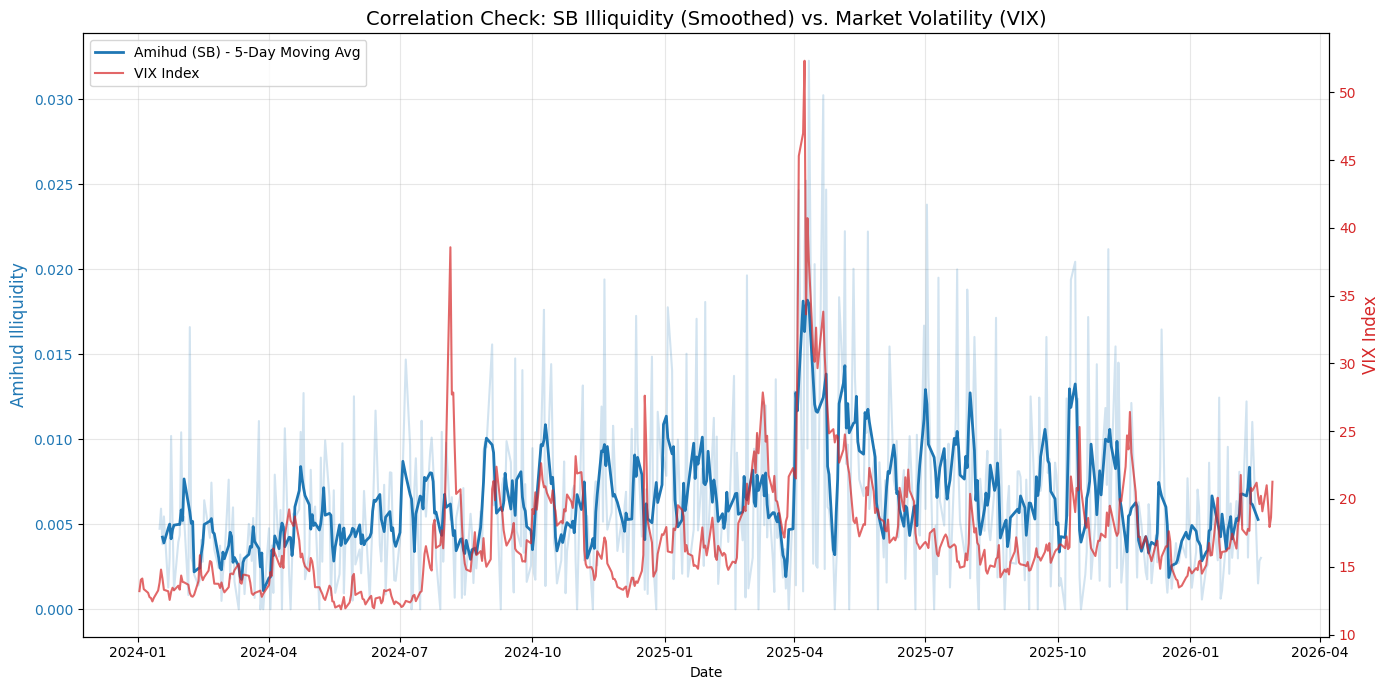

In [ ]:
# 1. Filter SB data and sort
sb_data = df_day[df_day['Ticker'] == 'SB'].copy().sort_values('Dates')

# --- IMPLEMENT ROLLING AVERAGE ---
# Using a 5-day window to smooth daily noise
# 'center=True' aligns the average with the middle of the 5-day window
sb_data['Amihud_Smoothed'] = sb_data['Amihud'].rolling(window=5, center=True).mean()

# 3. Create the plot structure
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Plot Amihud Illiquidity on the LEFT axis ---
color_ami = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Amihud Illiquidity', color=color_ami, fontsize=12)

# Plot Raw Data (Light/Faded)
ax1.plot(sb_data['Dates'], sb_data['Amihud'], color=color_ami, alpha=0.2, label='Amihud (SB) - Raw')

# Plot Smoothed Data (Bold/Solid)
lns1 = ax1.plot(sb_data['Dates'], sb_data['Amihud_Smoothed'], color=color_ami,
                label='Amihud (SB) - 5-Day Moving Avg', linewidth=2)

ax1.tick_params(axis='y', labelcolor=color_ami)

# --- Create the SECOND axis for VIX on the RIGHT ---
ax2 = ax1.twinx()
color_vix = 'tab:red'
ax2.set_ylabel('VIX Index', color=color_vix, fontsize=12)
lns2 = ax2.plot(df_VIX['Date'], df_VIX['Last Price'], color=color_vix,
                label='VIX Index', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_vix)

# 4. Combined Legend
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')

plt.title('Correlation Check: SB Illiquidity (Smoothed) vs. Market Volatility (VIX)', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

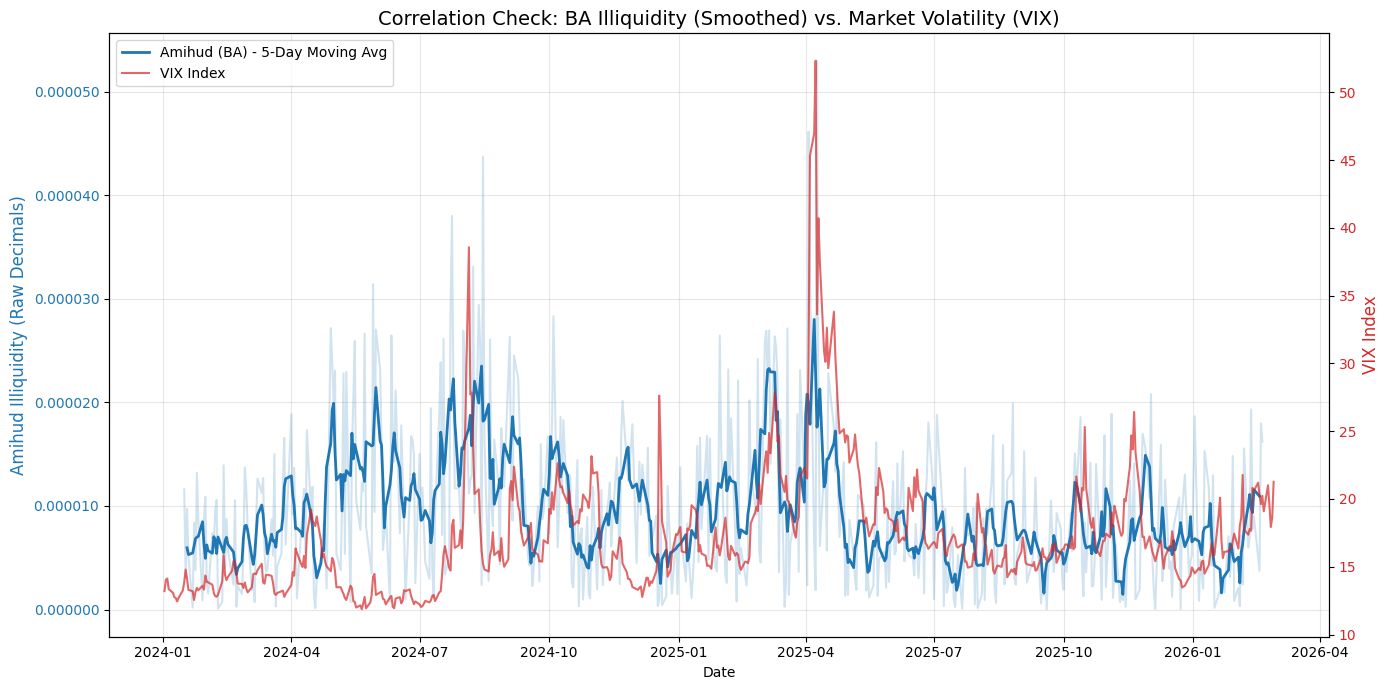

In [ ]:
# NB: run code, run once again the libraries, and then run this again (we dont know why this works that way)

# 1. Filter BA data and sort
ba_data = df_day[df_day['Ticker'] == 'BA'].copy().sort_values('Dates')

# --- IMPLEMENT ROLLING AVERAGE ---
# Using a 5-day window to smooth daily noise
ba_data['Amihud_Smoothed'] = ba_data['Amihud'].rolling(window=5, center=True).mean()

# 3. Create the plot structure
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Plot Amihud Illiquidity on the LEFT axis ---
color_ami = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Amihud Illiquidity (Raw Decimals)', color=color_ami, fontsize=12)

# Plot Raw Data (Light/Faded)
ax1.plot(ba_data['Dates'], ba_data['Amihud'], color=color_ami, alpha=0.2, label='Amihud (BA) - Raw')

# Plot Smoothed Data (Bold/Solid)
lns1 = ax1.plot(ba_data['Dates'], ba_data['Amihud_Smoothed'], color=color_ami,
                label='Amihud (BA) - 5-Day Moving Avg', linewidth=2)

# This forces the axis to show 0.00001 instead of "1" with a "1e-5" multiplier
formatter = ticker.ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax1.yaxis.set_major_formatter(formatter)
# Adjust the number in '%.6f' if you need more or fewer decimal places
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.6f'))

ax1.tick_params(axis='y', labelcolor=color_ami)

# --- Create the SECOND axis for VIX on the RIGHT ---
ax2 = ax1.twinx()
color_vix = 'tab:red'
ax2.set_ylabel('VIX Index', color=color_vix, fontsize=12)
lns2 = ax2.plot(df_VIX['Date'], df_VIX['Last Price'], color=color_vix,
                label='VIX Index', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_vix)

# 4. Combined Legend
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left')

plt.title('Correlation Check: BA Illiquidity (Smoothed) vs. Market Volatility (VIX)', fontsize=14)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
# Replace zeros with Nas
df_day["Amihud"] = df_day["Amihud"].replace(0, np.nan)
print("Amihud NaN count:", df_day["Amihud"].isna().sum())

Amihud NaN count: 124


Intrepretation:

Days with zero log returns, mainly in small-cap stocks, are excluded from the Amihud measure as they likely reflect stale prices rather than genuine zero illiquidity.

In [ ]:
# 1. Merge Amihud into pi_ti
comparison_df = pi_ti.merge(
    df_day[['Ticker', 'Dates', 'Amihud']],
    left_on=['Ticker', 'window_start'],
    right_on=['Ticker', 'Dates'],
    how='inner'
)

# 2. Merge Lambda from lambda_df
comparison_df = comparison_df.merge(
    lambda_df[['Ticker', 'window_start', 'Lambda']],
    on=['Ticker', 'window_start'],
    how='inner'
)

# 3. Create the Final Summary Table including Lambda
final_table = (
    comparison_df
    .groupby(["VIX_Regime", "Size"])[["Amihud", "Lambda", "PI", "TI"]]
    .mean()
)

# Optional: Scale the table for easier readability if the values are very small
# final_table[['Amihud_Illiq', 'Lambda']] *= 1e6

print("===== Comparative Liquidity Analysis =====")
final_table.head()

===== Comparative Liquidity Analysis =====


Amihud    Lambda        PI        TI
VIX_Regime Size                                         
High VIX   Large  0.000010  0.000007  0.930769 -0.012492
           Small  0.019510  0.000001  0.069627 -0.000440
Low VIX    Large  0.000010  0.000006  0.697067 -0.004571
           Small  0.030084  0.000002  0.056161  0.000804

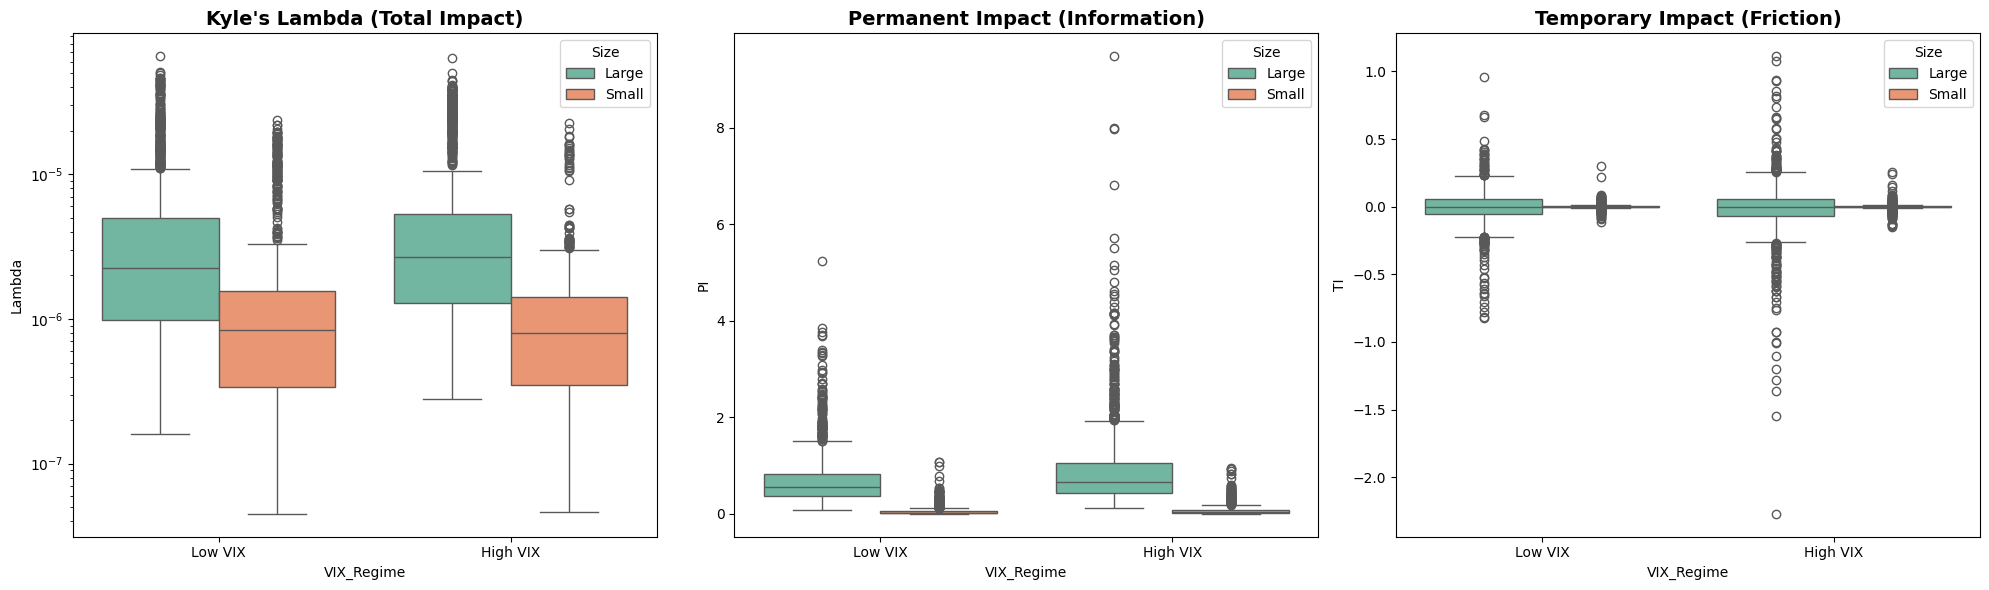

In [ ]:
# 1.
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 2. Select only 3 measures
measures = ['Lambda', 'PI', 'TI']
titles = ['Kyle\'s Lambda (Total Impact)',
          'Permanent Impact (Information)', 'Temporary Impact (Friction)']

for i, col in enumerate(measures):
    # 3.
    ax = axes[i]

    sns.boxplot(data=comparison_df, x='VIX_Regime', y=col, hue='Size', ax=ax, palette='Set2')
    ax.set_title(titles[i], fontsize=14, fontweight='bold')

    if col in ['Lambda']:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

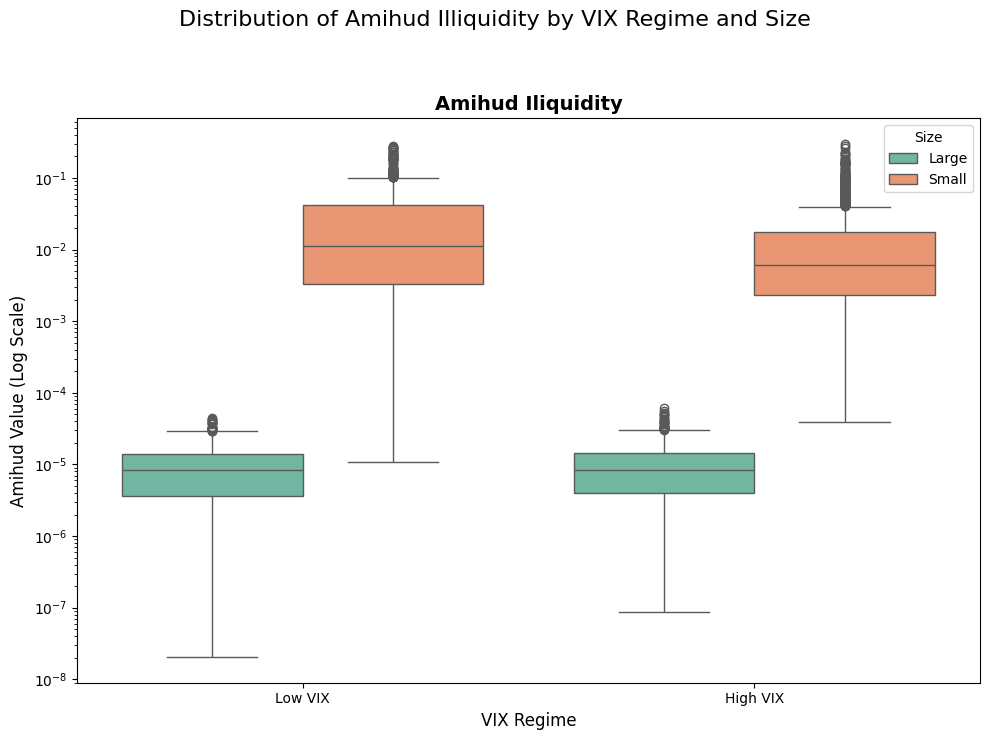

In [ ]:
# 1.
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# 2. Define your specific measure
col = 'Amihud'

# 3. Plotting
sns.boxplot(data=comparison_df, x='VIX_Regime', y=col, hue='Size', ax=ax, palette='Set2')

# 4. Customizing the labels and title
ax.set_title('Amihud Iliquidity', fontsize=14, fontweight='bold')
ax.set_xlabel('VIX Regime', fontsize=12)
ax.set_ylabel('Amihud Value', fontsize=12)

# 5. Scientific notation fix: Use log scale if outliers squash the boxes
# Amihud values are often so small that a log scale helps visualize the distribution
ax.set_yscale('log')
ax.set_ylabel('Amihud Value (Log Scale)')

# 6. Global Title
plt.suptitle('Distribution of Amihud Illiquidity by VIX Regime and Size', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

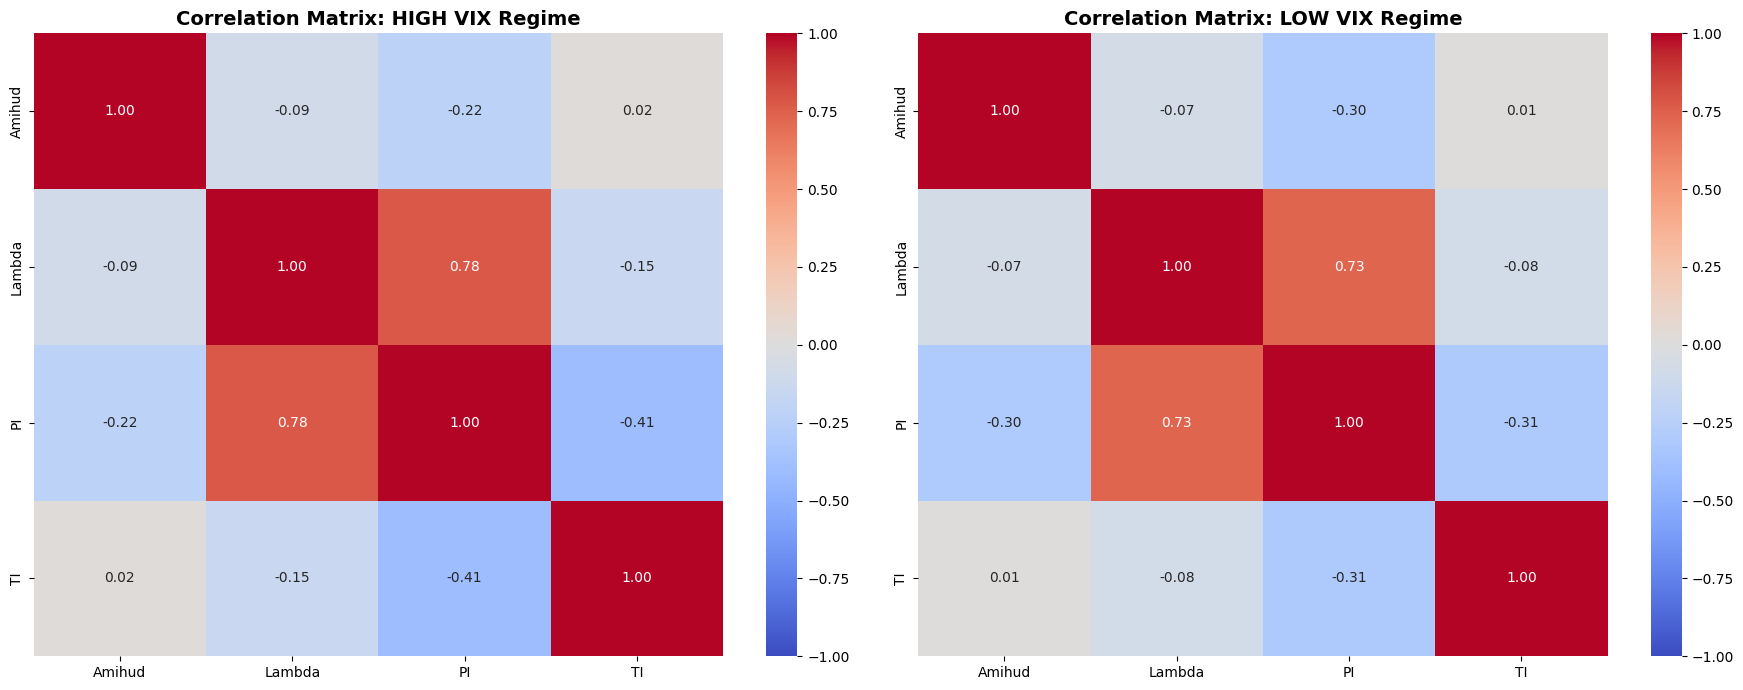

In [ ]:
# Select the measures for correlation
cols_to_corr = ['Amihud', 'Lambda', 'PI', 'TI']

# 1. Calculate for High VIX
high_vix_corr = comparison_df[comparison_df['VIX_Regime'] == 'High VIX'][cols_to_corr].corr()

# 2. Calculate for Low VIX
low_vix_corr = comparison_df[comparison_df['VIX_Regime'] == 'Low VIX'][cols_to_corr].corr()

# Plotting the heatmaps side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(high_vix_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax1, vmin=-1, vmax=1)
ax1.set_title('Correlation Matrix: HIGH VIX Regime', fontsize=14, fontweight='bold')

sns.heatmap(low_vix_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax2, vmin=-1, vmax=1)
ax2.set_title('Correlation Matrix: LOW VIX Regime', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Part D

In [ ]:
print(df_day.columns.tolist())

['Dates', 'Ticker', 'PX_LAST', 'PX_VOLUME', 'CUR_MKT_CAP', 'Log_Returns', 'D_VOL', 'Amihud']


In [ ]:
# Merge to make a panel
panel = pi_ti[["Ticker", "window_start", "PI", "TI", "HighVIX", "Size"]].copy()
panel = panel.rename(columns={"window_start": "Day"})

panel = panel.merge(
    lambda_df[["Ticker", "window_start", "Lambda"]].rename(columns={"window_start": "Day"}),
    on=["Ticker", "Day"],
    how="inner"
)

df_day_clean = df_day[["Ticker", "Dates", "Amihud"]].copy()
df_day_clean["Day"] = pd.to_datetime(df_day_clean["Dates"]).dt.normalize()

panel = panel.merge(
    df_day_clean[["Ticker", "Day", "Amihud"]],
    on=["Ticker", "Day"],
    how="inner"
)

panel["Small"] = (panel["Size"] == "Small").astype(int)
panel_d = panel.dropna(subset=["PI", "TI", "Lambda", "Amihud", "HighVIX"]).copy()
panel_d.head()

,Ticker,Day,PI,TI,HighVIX,Size,Lambda,Amihud,Small
0,BA,2024-01-16,1.033357,-0.213413,0,Large,8.546295e-07,1.161672e-05,0
1,BA,2024-01-17,0.670217,-0.025859,0,Large,7.126643e-07,3.077893e-06,0
2,BA,2024-01-18,0.741546,-0.041995,0,Large,8.622577e-07,9.722428e-06,0
3,BA,2024-01-19,1.057908,-0.158130,0,Large,1.363955e-06,5.182620e-06,0
4,BA,2024-01-22,1.054512,-0.171284,0,Large,1.440609e-06,1.810149e-07,0


In [ ]:
print("HighVIX distribution:\n", panel_d["HighVIX"].value_counts())
print("\nSmall distribution:\n", panel_d["Small"].value_counts())
print("\nTotal rows:", len(panel_d))
print("Unique tickers:", panel_d["Ticker"].nunique())
print("Unique days:", panel_d["Day"].nunique())

HighVIX distribution:
 HighVIX
1    2587
0    2509
Name: count, dtype: int64

Small distribution:
 Small
0    2605
1    2491
Name: count, dtype: int64

Total rows: 5096
Unique tickers: 10
Unique days: 522


In [ ]:
# Verify for serial correlation
for col in ["PI", "TI", "Lambda", "Amihud"]:
    resid = smf.ols(f"{col} ~ HighVIX + Small + HighVIX:Small", data=panel_d).fit().resid
    dw = durbin_watson(resid)
    print(f"{col}: Durbin-Watson = {dw:.4f}")

PI: Durbin-Watson = 0.0932
TI: Durbin-Watson = 0.4550
Lambda: Durbin-Watson = 0.0497
Amihud: Durbin-Watson = 0.8835


In [ ]:
# Newey West SE
for col in ["PI", "TI", "Lambda", "Amihud"]:
    df_reg = panel_d[["Ticker", "Day", col, "HighVIX", "Small"]].dropna()

    # Newey-West HAC standard errors (maxlags=5 accounts for weekly autocorrelation)
    model = smf.ols(
        f"{col} ~ HighVIX + Small + HighVIX:Small",
        data=df_reg
    ).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    b1 = model.params["HighVIX"]
    b2 = model.params["Small"]
    b3 = model.params["HighVIX:Small"]

    print(f"\n{'='*55}")
    print(f"  Illiquidity measure: {col}")
    print(f"{'='*55}")
    print(model.summary().tables[1])
    print(f"\n  β1 (crisis effect, large stocks):          {b1:.8f}")
    print(f"  β2 (small stock effect, normal times):     {b2:.8f}")
    print(f"  β3 (additional crisis effect, small):      {b3:.8f}")
    print(f"  β1+β3 (total crisis effect, small stocks): {b1+b3:.8f}")
    print(f"  R²: {model.rsquared:.4f}")
    print(f"  Adjusted R²: {model.rsquared_adj:.4f}")


  Illiquidity measure: PI
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.6980      0.031     22.654      0.000       0.638       0.758
HighVIX           0.2333      0.057      4.080      0.000       0.121       0.345
Small            -0.6401      0.031    -20.452      0.000      -0.701      -0.579
HighVIX:Small    -0.2200      0.058     -3.824      0.000      -0.333      -0.107

  β1 (crisis effect, large stocks):          0.23326622
  β2 (small stock effect, normal times):     -0.64008107
  β3 (additional crisis effect, small):      -0.21997413
  β1+β3 (total crisis effect, small stocks): 0.01329209
  R²: 0.3423
  Adjusted R²: 0.3419

  Illiquidity measure: TI
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0047    

In [ ]:
# Verify which model ran
print(model.cov_type)

HAC


Intrepretation:

We run the following regression for each of the four illiquidity measures (PI, TI, λ, Amihud):

**Illiquidity_i,d = α + β1·Crisis_d + β2·Small_i + β3·Crisis_d × Small_i + ε_i,d**

Standard errors are clustered at the stock (Ticker) level to account for within-firm serial correlation in illiquidity measures (obs from the same stock are correlated over t, so plain OLS standard errors would be biased downwards and inference would be unreliable).

R^2 and Adjusted R^2 are reported from an equivalent unclustered OLS model because clustering switches to a RobustResults object that does not expose
the R^2 attribute, even though the value is identical (R^2 depends only on fitted values and residuals, which are unchanged by the choice of standard errors).

Small dummy = 1 for small-cap stocks and 0 for large-cap defined based on market cap.

Crisis dummy (HighVIX) = 1 for days where VIX is above the sample median and 0 otherwise.

### Part E

In [ ]:
df["Day"] = df["Date"].dt.normalize()

# Compute daily PI, TI, and lambda by ticker * day
def estimate_daily_measures(group, min_obs=10):
    w = group.dropna(subset=["DeltaMP", "D", "DeltaD", "SignedSize"])
    n = len(w)
    if n < min_obs:
        return pd.Series({"PI": np.nan, "TI": np.nan, "Lambda": np.nan, "n_obs": n})
    y = w["DeltaMP"].astype(float)
    X_pi = sm.add_constant(w[["DeltaD", "D"]].astype(float))
    model_pi = sm.OLS(y, X_pi).fit()
    X_lam = sm.add_constant(w[["SignedSize"]].astype(float))
    model_lam = sm.OLS(y, X_lam).fit()
    return pd.Series({
        "PI": model_pi.params.get("D", np.nan),
        "TI": model_pi.params.get("DeltaD", np.nan),
        "Lambda": model_lam.params.get("SignedSize", np.nan),
        "n_obs": n
    })

daily_micro = (
    df.groupby(["Ticker", "Day"], group_keys=False)
      .apply(estimate_daily_measures)
      .reset_index()
)

print(daily_micro.head())
print("\nShape:", daily_micro.shape)
print("\nMissing values:")
print(daily_micro.isna().sum())

  Ticker        Day        PI        TI        Lambda  n_obs
0     BA 2024-01-12  0.405544 -0.023397  6.998800e-07   11.0
1     BA 2024-01-16  1.626576 -0.605913  9.760755e-07   13.0
2     BA 2024-01-17  0.732813 -0.029688  5.494889e-07   13.0
3     BA 2024-01-18  1.152361 -0.453729  6.715314e-07   13.0
4     BA 2024-01-19  0.547435  0.150444  8.866633e-07   13.0

Shape: (5270, 6)

Missing values:
Ticker     0
Day        0
PI        10
TI        10
Lambda    10
n_obs      0
dtype: int64


/tmp/ipykernel_954/3902371904.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_daily_measures)


In [ ]:
# Add next-day return to df_day (needed as dependent variable)
df_day["R_next"] = df_day.groupby("Ticker")["Log_Returns"].shift(-1)

# Build panel for regression
df_day_panel = df_day[["Ticker", "Dates", "R_next", "Amihud"]].rename(columns={"Dates": "Day"}).copy()
df_day_panel["Day"] = df_day_panel["Day"].dt.normalize()

# Merge with daily microstructure measures
panel = df_day_panel.merge(daily_micro[["Ticker", "Day", "PI", "TI", "Lambda"]], on=["Ticker", "Day"], how="inner")

# Drop rows with missing values
panel_reg = panel.dropna(subset=["R_next", "Amihud", "PI", "TI", "Lambda"]).copy()

print("Panel shape (before dropna):", panel.shape)
print("Panel_reg shape:", panel_reg.shape)
print("\nAny remaining NaNs")
print(panel_reg[["R_next", "Amihud", "PI", "TI", "Lambda"]].isna().sum())

Panel shape (before dropna): (5260, 7)
Panel_reg shape: (5119, 7)

Any remaining NaNs
R_next    0
Amihud    0
PI        0
TI        0
Lambda    0
dtype: int64


In [ ]:
print("Zero Amihud in panel_reg:", (panel_reg["Amihud"] == 0).sum())
print("NaN Amihud in panel:", panel["Amihud"].isna().sum())

Zero Amihud in panel_reg: 0
NaN Amihud in panel: 124


In [ ]:
panel_reg.head()

,Ticker,Day,R_next,Amihud,PI,TI,Lambda
0,BA,2024-01-16,0.012588,1.161672e-05,1.626576,-0.605913,9.760755e-07
1,BA,2024-01-17,0.041243,3.077893e-06,0.732813,-0.029688,5.494889e-07
2,BA,2024-01-18,0.015986,9.722428e-06,1.152361,-0.453729,6.715314e-07
3,BA,2024-01-19,-0.000419,5.182620e-06,0.547435,0.150444,8.866633e-07
4,BA,2024-01-22,-0.016087,1.810149e-07,0.480641,0.133804,9.306501e-07


In [ ]:
vix = pd.read_excel("VIX_History.xlsx")
vix["Day"] = pd.to_datetime(vix["Date"], dayfirst=True).dt.normalize()
vix["VIX"] = vix["Last Price"].astype(str).str.replace(",", ".", regex=False).astype(float)
vix["HighVIX"] = (vix["VIX"] >= vix["VIX"].median()).astype(int)

In [ ]:
# Regression
panel_reg = panel_reg.merge(vix[["Day", "HighVIX"]], on="Day", how="left")

large_caps = ["GS", "GE", "MCD", "DIS", "BA"]
panel_reg["Small"] = (~panel_reg["Ticker"].isin(large_caps)).astype(int)
panel_reg["Lambda_scaled"] = panel_reg["Lambda"] * 1e6

In [ ]:
#  Main regression (a)
model_a = smf.ols(
    formula="R_next ~ Amihud + Lambda_scaled + PI + TI + C(Ticker)",
    data=panel_reg
).fit(cov_type="cluster", cov_kwds={"groups": panel_reg["Ticker"]})

print("=== Part E(a): Main Regression ===")
print(model_a.summary())

# Interaction with illiquidity measures with HighVIX (c)
model_c = smf.ols(
    formula="""R_next ~ Amihud + Lambda_scaled + PI + TI
               + HighVIX:Amihud + HighVIX:Lambda_scaled + HighVIX:PI + HighVIX:TI
               + C(Ticker)""",
    data=panel_reg
).fit(cov_type="cluster", cov_kwds={"groups": panel_reg["Ticker"]})

print("\n=== Part E(c): VIX Interaction Regression ===")
print(model_c.summary())

# Key coefficients for c)
print("\nInteraction terms (do illiquidity effects differ in high-VIX times?):")
for var in ["HighVIX:Amihud", "HighVIX:Lambda_scaled", "HighVIX:PI", "HighVIX:TI"]:
    coef = model_c.params.get(var, np.nan)
    pval = model_c.pvalues.get(var, np.nan)
    print(f"  {var}: coef={coef:.6f}, p={pval:.3f}")

# Interact illiquidity measures with Small (d)
# Demean Amihud within size group to avoid multicollinearity
panel_reg["Amihud_demeaned"] = panel_reg.groupby("Small")["Amihud"].transform(
    lambda x: x - x.mean()
)

model_d = smf.ols(
    formula="""R_next ~ Amihud_demeaned + Lambda_scaled + PI + TI
               + Small:Amihud_demeaned + Small:Lambda_scaled + Small:PI + Small:TI""",
    data=panel_reg
).fit(cov_type="cluster", cov_kwds={"groups": panel_reg["Ticker"]})

print("\n=== Part E(d): Size Interaction Regression ===")
print(model_d.summary())

print("\nInteraction terms (do illiquidity effects differ for small stocks?):")
for var in ["Small:Amihud_demeaned", "Small:Lambda_scaled", "Small:PI", "Small:TI"]:
    coef = model_d.params.get(var, np.nan)
    pval = model_d.pvalues.get(var, np.nan)
    print(f"  {var}: coef={coef:.6f}, p={pval:.3f}")

=== Part E(a): Main Regression ===
                            OLS Regression Results                            
Dep. Variable:                 R_next   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     7.479
Date:                Tue, 03 Mar 2026   Prob (F-statistic):            0.00613
Time:                        18:09:16   Log-Likelihood:                 9838.9
No. Observations:                5119   AIC:                        -1.965e+04
Df Residuals:                    5105   BIC:                        -1.956e+04
Df Model:                          13                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Int

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 17, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# Check for correlation
model_check = smf.ols(
    "R_next ~ Amihud + Lambda_scaled + PI + TI + C(Ticker)",
    data=panel_reg
).fit()

dw = durbin_watson(model_check.resid)
print(f"Durbin-Watson: {dw:.4f}")

Durbin-Watson: 1.9987


In [ ]:
# Dealing with multicollinearity in part E(d)
vars_to_scale = ["Amihud", "Lambda_scaled", "PI", "TI"]
scaler = StandardScaler()

panel_reg_scaled = panel_reg.copy()
panel_reg_scaled[vars_to_scale] = scaler.fit_transform(panel_reg[vars_to_scale])

panel_reg_scaled["Amihud_demeaned"] = panel_reg_scaled.groupby("Small")["Amihud"].transform(
    lambda x: x - x.mean()
)

model_d = smf.ols(
    formula="""R_next ~ Amihud_demeaned + Lambda_scaled + PI + TI
               + Small:Amihud_demeaned + Small:Lambda_scaled + Small:PI + Small:TI""",
    data=panel_reg_scaled
).fit(cov_type="cluster", cov_kwds={"groups": panel_reg_scaled["Ticker"]})

print("\n=== Part E(d): Size Interaction Regression (Standardised) ===")
print(model_d.summary())


=== Part E(d): Size Interaction Regression (Standardised) ===
                            OLS Regression Results                            
Dep. Variable:                 R_next   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     225.2
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.90e-09
Time:                        18:09:24   Log-Likelihood:                 9833.1
No. Observations:                5119   AIC:                        -1.965e+04
Df Residuals:                    5110   BIC:                        -1.959e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------